In [1]:

# To load and inspect data
import pandas as pd
filepath = "C:/Users/USER/Downloads/uncertainty-medical-text/data"
def load_data(file_path, has_label=True):
    texts = []
    labels = []
    
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t', 1)
            if has_label:
                labels.append(parts[0])
                texts.append(parts[1])
            else:
                texts.append(line.strip())
    
    if has_label:
        return pd.DataFrame({'text': texts, 'label': labels})
    else:
        return pd.DataFrame({'text': texts})

train_df = load_data('data/train.dat', has_label=True)
test_df = load_data('data/test.dat', has_label=False)

print(train_df.head())
print(train_df['label'].value_counts())

                                                text label
0  Catheterization laboratory events and hospital...     4
1  Renal abscess in children. Three cases of rena...     5
2  Hyperplastic polyps seen at sigmoidoscopy are ...     2
3  Subclavian artery to innominate vein fistula a...     5
4  Effect of local inhibition of gamma-aminobutyr...     4
label
5    4805
1    3163
4    3051
3    1925
2    1494
Name: count, dtype: int64


In [2]:
# Basic Preprocessing
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    train_df['text'], 
    train_df['label'], 
    test_size=0.2, 
    random_state=42
)

In [3]:
# Convert Text → Features (TF-IDF)
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=3000,
    stop_words='english'
)

X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import LabelEncoder

# Vectorizer (lighter)
vectorizer = TfidfVectorizer(max_features=3000, stop_words='english')

X_train_vec = vectorizer.fit_transform(X_train)

# Encode labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)

# Fast model
model = SGDClassifier(loss='log_loss')
model.fit(X_train_vec, y_train_enc)

print("Training complete")

Training complete


In [5]:
# Evaluate Model
# Calibrated model - Platt Scaling
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(
    model,
    method='sigmoid',   # Platt scaling
    cv=3
)

calibrated_model.fit(X_train_vec, y_train_enc)




CalibratedClassifierCV(cv=3, estimator=SGDClassifier(loss='log_loss'))

In [7]:
# Calibrated Predeiction
import numpy as np
probs = calibrated_model.predict_proba(X_val_vec)
confidence = np.max(probs, axis=1)

# Predicted class (encoded)
pred_indices = np.argmax(probs, axis=1)

# Convert to labels
pred_labels = le.inverse_transform(pred_indices)


In [8]:
# Build Uncertainty analysis table
import pandas as pd

results_df = pd.DataFrame({
    'true': y_val.values,
    'pred': pred_labels,
    'confidence': confidence
})

# Correct or not
results_df['correct'] = results_df['true'] == results_df['pred']

print(results_df.head())

  true pred  confidence  correct
0    5    5    0.554952     True
1    1    5    0.454516    False
2    5    3    0.679450    False
3    3    3    0.474984     True
4    1    1    0.568455     True


In [9]:
#### Analyze Uncertainty: Compare accuracy vs confidence
# Analyze Uncertainty

# Create bins
results_df['conf_bin'] = pd.cut(results_df['confidence'], bins=5)

# Compute accuracy per bin
bin_accuracy = results_df.groupby('conf_bin')['correct'].mean()

print(bin_accuracy)

conf_bin
(0.255, 0.387]    0.441558
(0.387, 0.519]    0.503982
(0.519, 0.651]    0.603030
(0.651, 0.782]    0.752080
(0.782, 0.914]    0.837121
Name: correct, dtype: float64


C:\Users\USER\AppData\Local\Temp\ipykernel_5280\2565762013.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_accuracy = results_df.groupby('conf_bin')['correct'].mean()


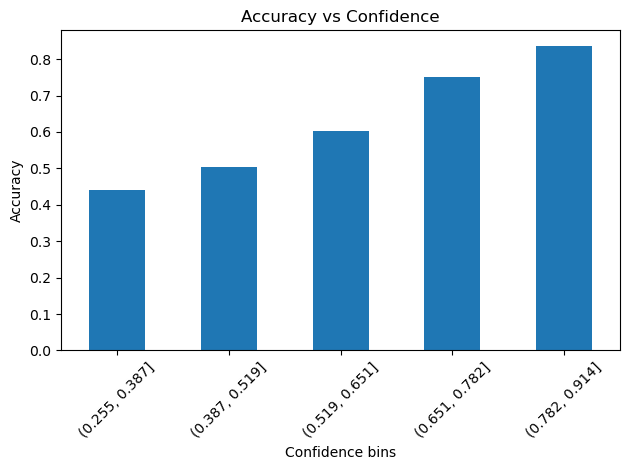

In [10]:
# Plot
import matplotlib.pyplot as plt

bin_accuracy.plot(kind='bar')
plt.title("Accuracy vs Confidence")
plt.ylabel("Accuracy")
plt.xlabel("Confidence bins")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
# Simulate Clinical Decision Threshold
threshold = 0.7

filtered = results_df[results_df['confidence'] >= threshold]

accuracy_filtered = filtered['correct'].mean()
coverage = len(filtered) / len(results_df)

print(f"Threshold: {threshold}")
print(f"Accuracy after filtering: {accuracy_filtered:.3f}")
print(f"Coverage: {coverage:.3f}")

Threshold: 0.7
Accuracy after filtering: 0.815
Coverage: 0.206


In [12]:
# Compare multiple thresholds
thresholds = [0.5, 0.6, 0.7, 0.8, 0.9]

for t in thresholds:
    filtered = results_df[results_df['confidence'] >= t]
    
    if len(filtered) > 0:
        acc = filtered['correct'].mean()
        cov = len(filtered) / len(results_df)
        
        print(f"Threshold {t}: Accuracy={acc:.3f}, Coverage={cov:.3f}")

Threshold 0.5: Accuracy=0.680, Coverage=0.693
Threshold 0.6: Accuracy=0.740, Coverage=0.427
Threshold 0.7: Accuracy=0.815, Coverage=0.206
Threshold 0.8: Accuracy=0.850, Coverage=0.071
Threshold 0.9: Accuracy=0.857, Coverage=0.002


In [13]:
# Predict Test set
X_test_vec = vectorizer.transform(test_df['text'])

test_probs = model.predict_proba(X_test_vec)

test_pred_indices = np.argmax(test_probs, axis=1)
test_pred_labels = le.inverse_transform(test_pred_indices)

test_confidence = np.max(test_probs, axis=1)

test_df['predicted_label'] = test_pred_labels
test_df['confidence'] = test_confidence

print(test_df.head())

                                                text predicted_label  \
0  Excision of limbal dermoids. We reviewed the c...               5   
1  Bell's palsy. A diagnosis of exclusion. In cas...               5   
2  Retained endobronchial foreign body removal fa...               5   
3  Recurrent buccal space abscesses: a complicati...               5   
4  Intracranial fibromatosis. Fibromatoses are un...               1   

   confidence  
0    0.448738  
1    0.612236  
2    0.477405  
3    0.449644  
4    0.481598  


In [14]:
# Uncertainity examples
low_conf = results_df.sort_values(by='confidence').head(10)

print(low_conf[['true', 'pred', 'confidence']])

     true pred  confidence
2342    2    5    0.255451
2742    1    1    0.259220
1721    4    3    0.270283
2673    3    3    0.270283
2412    1    5    0.275699
2744    2    1    0.280548
1703    5    3    0.283636
2288    5    3    0.294059
1872    1    1    0.296106
2082    5    1    0.296106


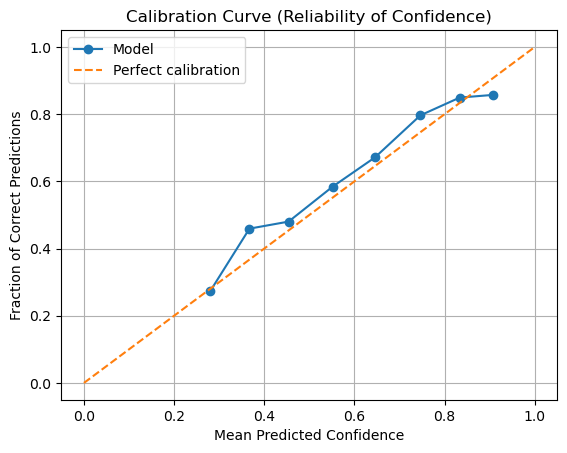

In [15]:
# Calibration Curve (Reliability of Probability)
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# Use probabilities of predicted class
prob_pos = confidence  # already max probability from your model

# Convert correctness to binary (1 = correct, 0 = wrong)
y_correct = results_df['correct'].astype(int)

# Calibration curve
fraction_of_positives, mean_predicted_value = calibration_curve(
    y_correct,
    prob_pos,
    n_bins=10
)

plt.plot(mean_predicted_value, fraction_of_positives, marker='o', label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")

plt.title("Calibration Curve (Reliability of Confidence)")
plt.xlabel("Mean Predicted Confidence")
plt.ylabel("Fraction of Correct Predictions")
plt.legend()
plt.grid()
plt.show()